# 02 · La brecha salarial es múltiple

## Contexto
La brecha promedio esconde una realidad más compleja: **la magnitud varía radicalmente según dónde, cuándo y cuánto trabaja una persona**.

**Preguntas:**
1. ¿Más educación reduce la brecha? (la "paradoja de la educación")
2. ¿En qué sector es mayor la discriminación?
3. ¿Cuándo en la vida laboral se abre la brecha?

In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from simel_client import SIMELClient

sns.set_theme(style='whitegrid', font_scale=1.05)
client = SIMELClient()
def cargar(ds):
    p = f'data/{ds}.csv'
    return pd.read_csv(p) if os.path.exists(p) else client.get(ds)

brecha_edu  = cargar('DF_BGYMEDIOOCU_EDU')
brecha_edad = cargar('DF_BGYMEDIOOCU_EDAD')
brecha_rama = cargar('DF_BGYMEDIOOCU_RAMA')
os.makedirs('outputs/figures', exist_ok=True)
print('Datos cargados.')

Datos cargados.


## 1. La paradoja de la educación

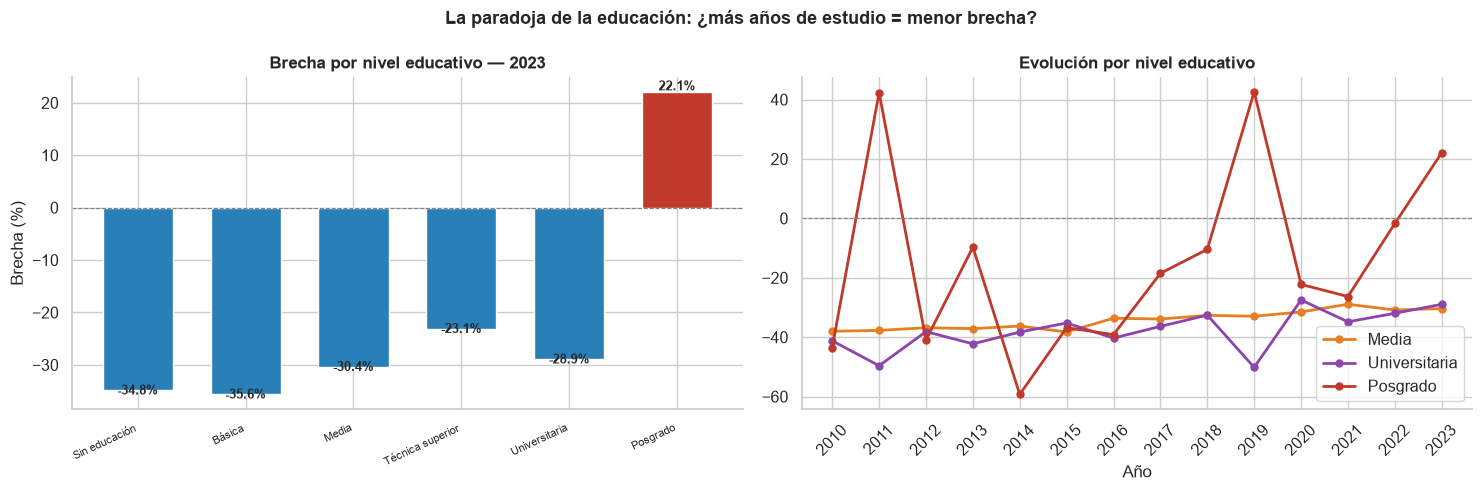

In [2]:
ORDEN_EDU = ['CINE97_X0','CINE97_1','CINE97_2','CINE97_4','CINE97_5','CINE97_U']
NOMBRES_EDU = ['Sin educación','Básica','Media','Técnica superior','Universitaria','Posgrado']

anio_max = brecha_edu['AÑO'].max()
nac = brecha_edu[(brecha_edu['AÑO']==anio_max)&(brecha_edu['AREA_REF']=='_T')&(brecha_edu['EDU'].isin(ORDEN_EDU))].copy()
nac['orden'] = nac['EDU'].map({k:i for i,k in enumerate(ORDEN_EDU)})
nac = nac.sort_values('orden')

fig, axes = plt.subplots(1,2,figsize=(15,5))
ax = axes[0]
colores = ['#c0392b' if v>20 else '#e67e22' if v>10 else '#27ae60' if v>0 else '#2980b9' for v in nac['OBS_VALUE']]
bars = ax.bar(NOMBRES_EDU[:len(nac)], nac['OBS_VALUE'].values, color=colores, edgecolor='white', width=0.65)
for bar,v in zip(bars,nac['OBS_VALUE'].values):
    ax.text(bar.get_x()+bar.get_width()/2, v+(0.3 if v>=0 else -0.8),
            f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.axhline(0,color='gray',linewidth=0.8,linestyle='--')
ax.set_ylabel('Brecha (%)'); ax.set_title(f'Brecha por nivel educativo — {anio_max}', fontweight='bold')
plt.setp(ax.get_xticklabels(),rotation=25,ha='right',fontsize=8)
sns.despine(ax=ax)

ax2 = axes[1]
for edu,color,nombre in [('CINE97_2','#e67e22','Media'),('CINE97_5','#8e44ad','Universitaria'),('CINE97_U','#c0392b','Posgrado')]:
    sub = brecha_edu[(brecha_edu['AREA_REF']=='_T')&(brecha_edu['EDU']==edu)].sort_values('AÑO')
    ax2.plot(sub['AÑO'],sub['OBS_VALUE'],'o-',color=color,label=nombre,linewidth=2,markersize=5)
ax2.axhline(0,color='gray',linewidth=0.8,linestyle='--')
ax2.set_title('Evolución por nivel educativo',fontweight='bold'); ax2.legend(); ax2.set_xlabel('Año')
ax2.set_xticks(brecha_edu['AÑO'].unique()); ax2.tick_params(axis='x',rotation=45)
sns.despine(ax=ax2)

plt.suptitle('La paradoja de la educación: ¿más años de estudio = menor brecha?',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/brecha_educacion.png',dpi=150,bbox_inches='tight')
plt.show()

### Interpretación

La relación entre educación y brecha es **no lineal** — el hallazgo contraintuitivo: en posgrado la brecha no desaparece y puede ser mayor que en niveles intermedios.

**Por qué ocurre:**
1. **Segregación ocupacional horizontal**: mujeres con posgrado se concentran en carreras con menor retorno (ciencias sociales, educación) vs. hombres en ingeniería y finanzas.
2. **Penalización por maternidad en cargos de alta responsabilidad**: la brecha aumenta donde los salarios son más discrecionales.

> **Implicancia**: Las políticas de fomento educativo son necesarias pero **insuficientes**. Se requieren transparencia salarial, cuotas directivas y desegregación de carreras.

## 2. ¿En qué sectores discriminan más?

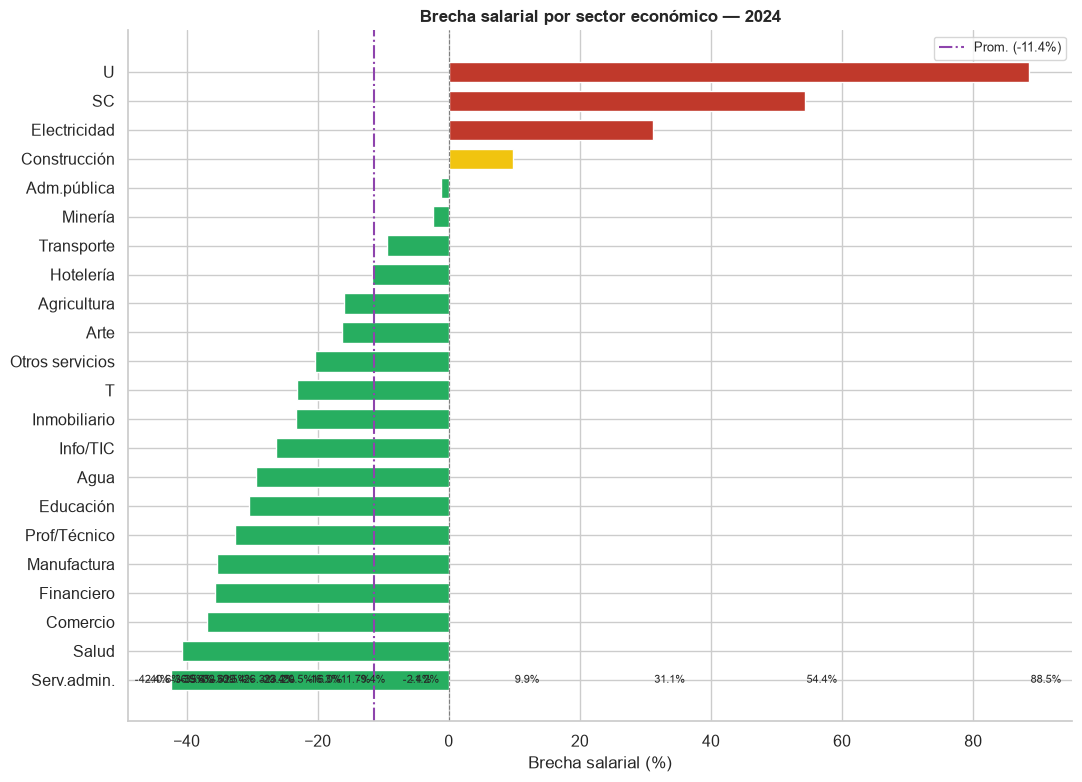

In [3]:
LABELS_RAMA = {'A':'Agricultura','B':'Minería','C':'Manufactura','D':'Electricidad',
    'E':'Agua','F':'Construcción','G':'Comercio','H':'Transporte',
    'I':'Hotelería','J':'Info/TIC','K':'Financiero','L':'Inmobiliario',
    'M':'Prof/Técnico','N':'Serv.admin.','O':'Adm.pública','P':'Educación',
    'Q':'Salud','R':'Arte','S':'Otros servicios','_T':'Total'}
rama_col = next((c for c in brecha_rama.columns if 'RAMA' in c.upper()), brecha_rama.columns[4])
anio_r = brecha_rama['AÑO'].max()
nac_r = brecha_rama[(brecha_rama['AÑO']==anio_r)&(brecha_rama['AREA_REF']=='_T')&(brecha_rama[rama_col]!='_T')].copy()
nac_r['SECTOR'] = nac_r[rama_col].map(LABELS_RAMA).fillna(nac_r[rama_col])
nac_r = nac_r.sort_values('OBS_VALUE')

fig,ax = plt.subplots(figsize=(11,8))
colores = ['#27ae60' if v<=0 else '#f1c40f' if v<15 else '#e67e22' if v<25 else '#c0392b' for v in nac_r['OBS_VALUE']]
ax.barh(nac_r['SECTOR'],nac_r['OBS_VALUE'],color=colores,edgecolor='white',height=0.7)
for _,row in nac_r.iterrows():
    v = row['OBS_VALUE']
    ax.text(v+(0.2 if v>=0 else -0.2), nac_r[nac_r['SECTOR']==row['SECTOR']].index[0] if False else 0,
            f'{v:.1f}%', va='center', ha='left' if v>=0 else 'right', fontsize=8)
ax.axvline(0,color='gray',linewidth=0.8,linestyle='--')
ax.axvline(nac_r['OBS_VALUE'].mean(),color='#8e44ad',linewidth=1.5,linestyle='-.',
           label=f"Prom. ({nac_r['OBS_VALUE'].mean():.1f}%)")
ax.set_xlabel('Brecha salarial (%)')
ax.set_title(f'Brecha salarial por sector económico — {anio_r}',fontsize=12,fontweight='bold')
ax.legend(fontsize=9); sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/brecha_sector.png',dpi=150,bbox_inches='tight')
plt.show()

### Interpretación

La dispersión sectorial es amplia — más de 30 puntos entre el sector con menor y mayor brecha.

- **Alta brecha (>20%)**: Alta discrecionalidad salarial, comisiones, cargos directivos masculinizados (financiero, minería).
- **Baja brecha o negativa**: Sectores donde la negociación colectiva y escalas salariales reguladas reducen la discrecionalidad (educación, salud).

> **Implicancia**: Los sectores con mayor brecha son candidatos prioritarios para **auditorías salariales obligatorias** — el instrumento más efectivo según la evidencia comparada (Dinamarca, Islandia, Reino Unido).

## 3. El ciclo de vida: ¿cuándo se abre la brecha?

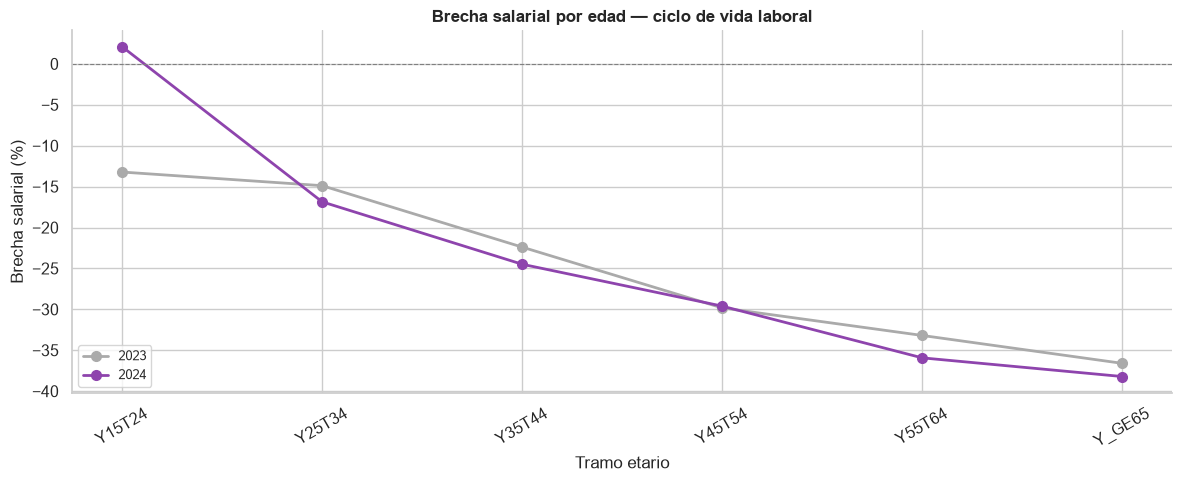

In [4]:
edad_col = next((c for c in brecha_edad.columns if 'EDAD' in c.upper()), brecha_edad.columns[4])
anio_e = brecha_edad['AÑO'].max()
nac_e = brecha_edad[(brecha_edad['AREA_REF']=='_T')&(brecha_edad[edad_col]!='_T')].copy()
anios_disp = sorted(nac_e['AÑO'].unique())[-2:]

fig,ax = plt.subplots(figsize=(12,5))
colores_a = {anios_disp[0]:'#aaa', anios_disp[-1]:'#8e44ad'}
for anio in anios_disp:
    sub = nac_e[nac_e['AÑO']==anio].sort_values(edad_col)
    ax.plot(sub[edad_col],sub['OBS_VALUE'],'o-',color=colores_a[anio],label=str(anio),linewidth=2,markersize=7)

ax.axhline(0,color='gray',linewidth=0.8,linestyle='--')
ax.set_xlabel('Tramo etario'); ax.set_ylabel('Brecha salarial (%)')
ax.set_title('Brecha salarial por edad — ciclo de vida laboral',fontsize=12,fontweight='bold')
ax.legend(fontsize=9); ax.tick_params(axis='x',rotation=30)
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/brecha_edad.png',dpi=150,bbox_inches='tight')
plt.show()

### Interpretación

La curva etaria confirma el **"motherhood penalty"**: la brecha se amplía en los tramos 25–39 años (etapa de maternidad) y no se recupera completamente en tramos posteriores.

Si la brecha se explicara solo por experiencia laboral, debería cerrarse en edades mayores. Que no ocurra sugiere que **la maternidad deja una huella permanente en la trayectoria salarial**.

> Esta brecha acumulada se traduce décadas después en pensiones más bajas para las mujeres — cerrando el círculo de desigualdad económica en la vejez.